# ♀️♂️ Genders dataset — EDA and preprocessing

Copenhagen Networks Study, `genders.csv`: `user_id`, `is_female` (binary).
Per the project README, gender is **optional descriptive metadata only** —
it must never drive individual decisions or predictions, only aggregate
description.

This dataset has no continuous numeric column, so steps (3) and (4) from
the checklist don't apply in their usual form — they are replaced by the
two things that actually matter here: **participant coverage** (is every
enrolled participant represented?) and **class balance** (is `is_female`
skewed?), which is exactly the imbalance question raised earlier in this
project. Steps covered: **(1) duplicates → (2) missing data / coverage →
(3) class balance → (4) encoding check**, reusing `src/features/eda.py`.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from src.data.io import (
    load_facebook_data,
    load_gender_data,
    load_telecom_data,
    write_processed_data,
)
from src.features import eda

RAW_DIR = PROJECT_ROOT / "data" / "raw" / "7267433"
%matplotlib inline

In [2]:
data = load_gender_data(RAW_DIR / "genders.csv")
print(data.shape)
data.head()

(787, 2)


,user_id,is_female
0,0,0
1,2,0
2,3,0
3,4,0
4,5,0


## (1) Duplicates

Check both exact duplicate rows and duplicate `user_id`s (the same
participant listed twice, possibly with conflicting gender values — a real
data-quality problem, not just redundancy).

In [3]:
eda.duplicate_report(data), eda.duplicate_report(data, subset=["user_id"])

({'n_rows': 787, 'n_duplicate_rows': 0, 'pct_duplicate_rows': 0.0},
 {'n_rows': 787, 'n_duplicate_rows': 0, 'pct_duplicate_rows': 0.0})

**Decision:** `0` duplicate rows and `0` duplicate `user_id`s — every
participant appears exactly once. Nothing to drop.

## (2) Missing data

`missingness_report` only catches missing *cells* — but this file's real
missing-data problem is at the **row level**: some enrolled participants
who appear in other datasets have no row here at all. That's invisible to a
per-column NaN count, so it needs its own check against the participant IDs
seen elsewhere (`calls`, `sms`, `fb_friends` — `bt_symmetric` omitted here
since it is far larger and covered separately by the pipeline's
`coverage.parquet`).

In [4]:
eda.missingness_report(data)

,n_missing,pct_missing
user_id,0,0.0
is_female,0,0.0


In [5]:
calls = load_telecom_data(RAW_DIR / "calls.csv", log_type="calls")
sms = load_telecom_data(RAW_DIR / "sms.csv")
fb_friends = load_facebook_data(RAW_DIR / "fb_friends.csv")

known_participant_ids = (
    set(calls["caller"]) | set(calls["callee"])
    | set(sms["sender"]) | set(sms["recipient"])
    | set(fb_friends["user_a"]) | set(fb_friends["user_b"])
    | set(data["user_id"])
)
missing_gender_ids = known_participant_ids - set(data["user_id"])

n_known = len(known_participant_ids)
n_missing = len(missing_gender_ids)
n_known, n_missing, round(100 * n_missing / n_known, 2)

(844, 57, 6.75)

**Decision:** within the file, `0` cells are missing — but **57 of
844 known participants (~6.8%)** have no gender row at all. This is a
structural coverage gap (participants who didn't report gender), not
random missingness, and per the README's ethics section gender must stay
**aggregate/descriptive only**. Fabricating a label for participants who
did not report one — via `SimpleImputer` or any other method — would be
both statistically unjustified and against that constraint. These 57
participants are left absent; any later merge against `genders` should
expect `NaN`/"unknown" for them rather than assume full coverage.

## (3) Class balance (in place of outliers)

`is_female` is binary, so IQR-style outlier detection doesn't apply. The
equivalent question for a categorical column is **class balance** — this is
the imbalance concern raised earlier in this project.

In [6]:
counts = data["is_female"].value_counts().rename_axis("is_female").rename("n_participants")
proportions = (data["is_female"].value_counts(normalize=True) * 100).round(2)
counts, proportions

(is_female
 0    614
 1    173
 Name: n_participants, dtype: int64,
 is_female
 0    78.02
 1    21.98
 Name: proportion, dtype: float64)

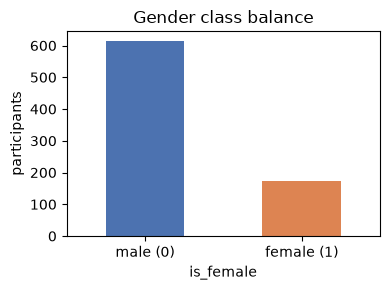

In [7]:
fig, ax = plt.subplots(figsize=(4, 3))
counts.sort_index().plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_xticklabels(["male (0)", "female (1)"], rotation=0)
ax.set_ylabel("participants")
ax.set_title("Gender class balance")
fig.tight_layout()

**Decision:** the split is skewed (~78% male / ~22% female) — a real
class imbalance, not a bug. This project doesn't train a classifier with
gender as the prediction target today, so the raw counts are kept exactly
as reported (no synthetic participants added, no real participants
dropped) — but the imbalance is corrected for via per-row **class
weights**, computed in step (5) below, rather than left unaddressed.

## (4) Encoding check (in place of scaling)

No continuous magnitude exists to scale. Checking whether an
**ordinal encoder** would add anything: it wouldn't — `is_female` only has
two categories and there is no inherent order between "male" and "female"
to encode (a true ordinal column would be something ranked, like
low/medium/high). The same is true across the other four datasets:
`caller`/`callee`/`sender`/`recipient`/`user_a`/`user_b` are anonymous
**nominal** participant IDs, not ordered categories — running them through
an ordinal encoder would fabricate a false ranking between participants
that doesn't exist. So `OrdinalEncoder` isn't applied anywhere in this
project; confirm below that it would just reproduce the 0/1 representation
`is_female` already has.

In [8]:
from sklearn.preprocessing import OrdinalEncoder

gender_labels = data["is_female"].map({0: "male", 1: "female"}).to_frame("gender_label")
encoder = OrdinalEncoder(categories=[["male", "female"]])
encoded = encoder.fit_transform(gender_labels)[:, 0]
(encoded == data["is_female"].to_numpy()).all()

np.True_

## (5) Balancing

Instead of resampling to fix the ~78/22 split — oversampling would
fabricate synthetic participant records (and there are no other features
in this file to interpolate over anyway, so SMOTE isn't even applicable),
and undersampling would discard real reported data from an already small
787-row file — attach a per-row **class weight** so a downstream model can
correct for the skew without altering who is actually in the data.

In [9]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.array([0, 1])
weights = compute_class_weight(class_weight="balanced", classes=classes, y=data["is_female"])
class_weight_map = dict(zip(classes.tolist(), weights.tolist()))
class_weight_map

{0: 0.6408794788273615, 1: 2.2745664739884393}

In [10]:
data["is_female_class_weight"] = data["is_female"].map(class_weight_map)
data[["user_id", "is_female", "is_female_class_weight"]].head()

,user_id,is_female,is_female_class_weight
0,0,0,0.640879
1,2,0,0.640879
2,3,0,0.640879
3,4,0,0.640879
4,5,0,0.640879


**Decision:** `is_female_class_weight` holds the inverse-frequency weight
for each row's class (`compute_class_weight("balanced", ...)`)  — pass it
as `sample_weight` to a classifier to correct for the imbalance at training
time. This is the standard, safe way to handle class imbalance without
touching which participants are actually present in the data.

## Result

`data` is the prepared dataframe for `genders.csv`:

- 0 duplicate rows / duplicate `user_id`s.
- 0 missing cells, but a documented **6.8% participant coverage gap**
  (57 of 844 known IDs have no gender row) — intentionally left
  unimputed per the project's ethics constraint on gender data.
- Class imbalance (~78/22) documented; `is_female_class_weight` attached
  so a model can correct for it without resampling real participants.
- `is_female` confirmed equivalent to what `OrdinalEncoder` would produce
  — already in a directly usable binary encoding, no transform needed.

Saved separately from the raw pass-through `genders.parquet` produced by
`main.py`/`export_secondary_datasets`.

In [11]:
output_path = write_processed_data(data, PROJECT_ROOT / "data" / "processed", "genders_prepared.parquet")
output_path

PosixPath('/home/johnny/master_uu/UU-DataMining-2026/data/processed/genders_prepared.parquet')